# Ejercicios con NumPy y Matplotlib
Comparación de la edad materna media en México y Japón.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

In [2]:
url_datos = (
    "https://ourworldindata.org/grapher/children-born-per-woman.csv"
    "?v=1&csvType=full&useColumnShortNames=true"
)
url_metadata = (
    "https://ourworldindata.org/grapher/children-born-per-woman.metadata.json"
    "?v=1&csvType=full&useColumnShortNames=true"
)

df = pd.read_csv(
    url_datos,
    storage_options={"User-Agent": "Our World In Data data fetch/1.0"},
)
respuesta_metadata = requests.get(url_metadata, timeout=30)
respuesta_metadata.raise_for_status()
metadata = respuesta_metadata.json()

In [3]:
df.describe()

,year,fertility_rate_hist
count,19402.000000,19402.000000
mean,1985.861612,3.936123
std,22.049134,1.991179
min,1891.000000,0.662000
25%,1967.000000,2.138210
50%,1986.000000,3.466000
75%,2005.000000,5.849000
max,2023.000000,8.864000


In [4]:
df.columns.tolist()

['entity', 'code', 'year', 'fertility_rate_hist']

In [5]:
mexico = df.loc[df["entity"] == "Mexico"].copy()
japan = df.loc[df["entity"] == "Japan"].copy()

In [6]:
anios_mexico = mexico["year"].to_numpy()
tasa_fertilidad_mexico = mexico["fertility_rate_hist"].to_numpy()

anios_japon = japan["year"].to_numpy()
tasa_fertilidad_japon = japan["fertility_rate_hist"].to_numpy()

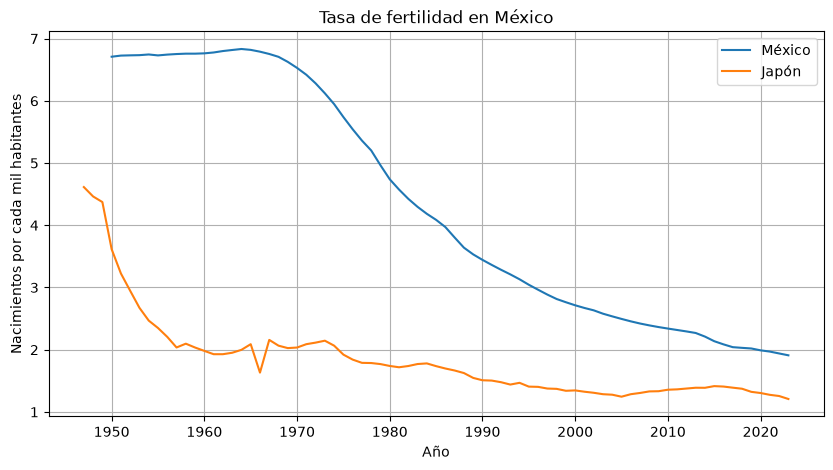

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(anios_mexico, tasa_fertilidad_mexico, label="México")
plt.plot(anios_japon, tasa_fertilidad_japon, label="Japón")
plt.title("Tasa de fertilidad en México")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada mil habitantes")
plt.grid(True)
plt.legend()
plt.show()

In [8]:
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()
mascara_coincidencia_anios

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [9]:
anios_japon = anios_japon[mascara_coincidencia_anios]

In [10]:
tasa_japon_filtrada = tasa_fertilidad_japon[mascara_coincidencia_anios]

In [11]:
anios_japon.shape

(74,)

In [12]:
diferencia_ex_jp = tasa_fertilidad_mexico - tasa_japon_filtrada

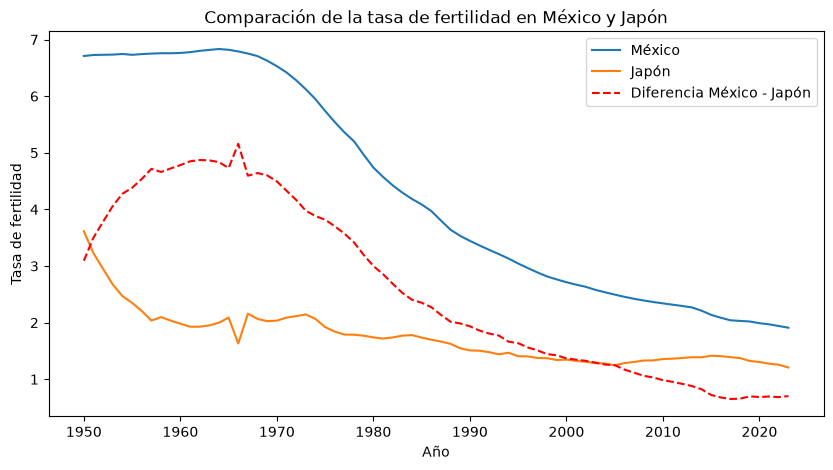

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(anios_mexico, tasa_fertilidad_mexico, label='México')
plt.plot(anios_japon, tasa_japon_filtrada, label='Japón')
plt.plot(anios_mexico, diferencia_ex_jp, label='Diferencia México - Japón', linestyle='--', color='red')
 
plt.xlabel('Año')
plt.ylabel('Tasa de fertilidad')
plt.title('Comparación de la tasa de fertilidad en México y Japón')
plt.legend()
plt.show()
 

In [14]:
print(anios_japon[39])

1989


In [15]:
anios_comunes = np.intersect1d(mexico["year"].to_numpy(), japan["year"].to_numpy())

mexico_anios_comunes = (
    mexico[mexico["year"].isin(anios_comunes)]
    .sort_values("year")
    .reset_index(drop=True)
)
japon_anios_comunes = (
    japan[japan["year"].isin(anios_comunes)]
    .sort_values("year")
    .reset_index(drop=True)
)

In [16]:
mascara_tasas_validas = (
    mexico_anios_comunes["fertility_rate_hist"].notna().to_numpy()
    & japon_anios_comunes["fertility_rate_hist"].notna().to_numpy()
)

mexico_anios_comunes = mexico_anios_comunes.loc[mascara_tasas_validas]
japon_anios_comunes = japon_anios_comunes.loc[mascara_tasas_validas]

In [17]:
mex_anios_comunes = mexico_anios_comunes["year"].to_numpy()
jpn_anios_comunes = japon_anios_comunes["year"].to_numpy()

mex_tasa_comunes = mexico_anios_comunes["fertility_rate_hist"].to_numpy()
jpn_tasa_comunes = japon_anios_comunes["fertility_rate_hist"].to_numpy()

In [18]:
print(anios_japon[30])

1980


In [19]:
anios_japon = np.delete(anios_japon, 39)

In [20]:
mexico.head(10)

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731
11128,Mexico,MEX,1953,6.734
11129,Mexico,MEX,1954,6.745
11130,Mexico,MEX,1955,6.730
11131,Mexico,MEX,1956,6.743
11132,Mexico,MEX,1957,6.752
11133,Mexico,MEX,1958,6.758
11134,Mexico,MEX,1959,6.758


In [21]:
japan.head(10)

,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373
8387,Japan,JPN,1950,3.615
8388,Japan,JPN,1951,3.225
8389,Japan,JPN,1952,2.947
8390,Japan,JPN,1953,2.673
8391,Japan,JPN,1954,2.468
8392,Japan,JPN,1955,2.349
8393,Japan,JPN,1956,2.206


In [22]:
comparacion_mexico_japon = pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    japan[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico", "_japon")
)

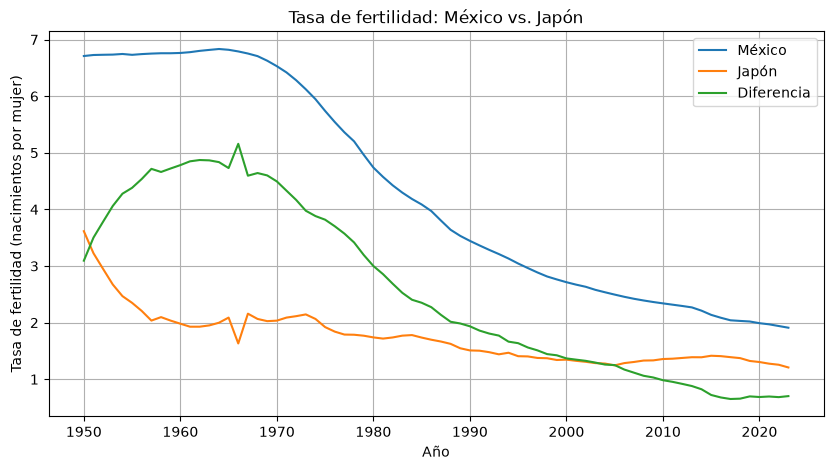

In [23]:
comparacion_mexico_japon["diferencia"] = (
    comparacion_mexico_japon["fertility_rate_hist_mexico"]
    - comparacion_mexico_japon["fertility_rate_hist_japon"]
)

figura, eje = plt.subplots(figsize=(10, 5))
comparacion_mexico_japon.plot(
    x="year",
    y=[
        "fertility_rate_hist_mexico",
        "fertility_rate_hist_japon",
        "diferencia",
    ],
    kind="line",
    ax=eje,
)

eje.set_xlabel("Año")
eje.set_ylabel("Tasa de fertilidad (nacimientos por mujer)")
eje.set_title("Tasa de fertilidad: México vs. Japón")
eje.grid(True)
eje.legend(["México", "Japón", "Diferencia"])
plt.show()